# 02 - optical link + crosstalk model (SW-O*)
dB budget + crosstalk vs pitch. sets where thresholds should sit.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
# quick path hack so the repo modules import from notebooks/


In [2]:
#MD ## link budget hand-check (SW-O2)

In [3]:
from touch_sensing import received_power_dbm, crosstalk_ratio, linear_to_db
p_rx = received_power_dbm(0.0, 1.0, 0.6, 2.0, 3.0)
print("P_rx =", p_rx, "dBm")
assert abs(p_rx - (-7.4)) < 1e-9    # 2+2.4+3 = 7.4 dB loss, checks out

P_rx = -7.4 dBm


In [4]:
#MD ## longer fiber loses more (SW-O3)

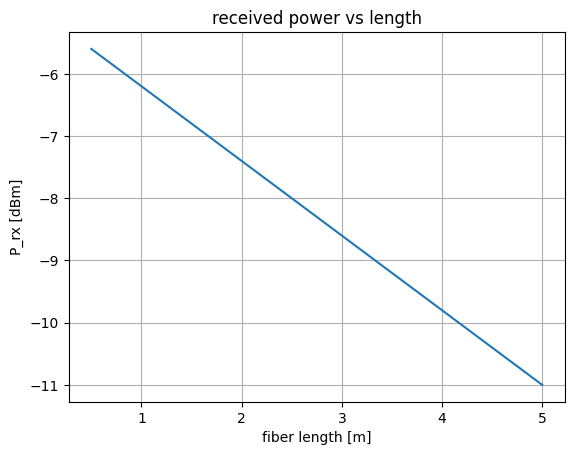

In [5]:
Ls = np.linspace(0.5, 5, 30)
pr = [received_power_dbm(0,1,0.6,L,3) for L in Ls]
plt.plot(Ls, pr); plt.xlabel("fiber length [m]"); plt.ylabel("P_rx [dBm]")
plt.title("received power vs length"); plt.grid(True); plt.show()
assert pr[-1] < pr[0]   # yep monotonic down

In [6]:
#MD ## crosstalk vs pixel pitch (SW-O4)

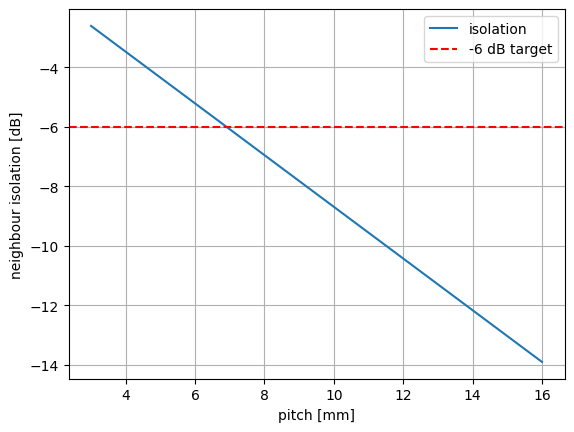

In [7]:
pitch = np.linspace(3, 16, 40)
ct_db = [linear_to_db(crosstalk_ratio(x, 5.0)) for x in pitch]
plt.plot(pitch, ct_db, label="isolation")
plt.axhline(-6, ls="--", color="r", label="-6 dB target")
plt.xlabel("pitch [mm]"); plt.ylabel("neighbour isolation [dB]")
plt.legend(); plt.grid(True); plt.show()
# need pitch past the dashed line for >6dB isolation. ~9mm ish